In [1]:
# this is a tutorial about Q-learning. 
# reference: https://pythonprogramming.net/q-learning-reinforcement-learning-python-tutorial/


In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import gym

# Explore MountainCar-v0 

In [3]:
env = gym.make("MountainCar-v0")

print('action space:', env.action_space)   #  0: push left, 1: no push, 2: push right
print('state lower limits:', env.observation_space.low)  # lower boundaries of states
print('state higher limits:', env.observation_space.high) # higher boundaries of states
print('state tensor:', env.observation_space)      # observation space

state = env.reset()    # return an intial state: [location, velocity]

print('initial state:', state)


action space: Discrete(3)
state lower limits: [-1.2  -0.07]
state higher limits: [0.6  0.07]
state tensor: Box(-1.2000000476837158, 0.6000000238418579, (2,), float32)
initial state: [-0.41792878  0.        ]


In [4]:


done = False
steps = 0
while not done:
    steps += 1
    action = 2  # always push right!
    new_state, reward, end, _= env.step(action)    # excute one step 
    env.render()  # display
    print(new_state, reward, end)
    if steps >= 5:
        break
print(env.goal_position)

[-4.17708097e-01  2.20682669e-04] -1.0 False
[-0.4172683   0.00043979] -1.0 False
[-0.41661253  0.00065577] -1.0 False
[-0.41574545  0.00086708] -1.0 False
[-0.41467324  0.00107222] -1.0 False
0.5


# define Q table

In [5]:
# state = [x, v], x is the horizontal position of the car, x=0.5 for the flag (goal), x=-0.5 for the bottom
# v is the velocity (positive for right direction)

In [6]:

#state_dimension = [20, 20]   # discrete state dimension: 20 by 20
STATE_DIMENSION = [20] * len(env.observation_space.high)  # [20,20]
STATE_GRID_SIZE = (env.observation_space.high - env.observation_space.low)/STATE_DIMENSION
# unit size

print(STATE_GRID_SIZE)

[0.09  0.007]


In [7]:
q_table = np.random.uniform(low=-2, high=0, size=(STATE_DIMENSION + [env.action_space.n]))

# create a q-table (20,20,3) with initial random numbers, dimension: (x, v, a)
# all rewards are -1, except the goal (flag) reward is 0.
# so we initialize Q values to be negative

In [8]:
print(q_table.shape)

(20, 20, 3)


In [9]:
# convert continuous state value into discrete integers, which will be used as the indices of q_table
def get_discrete_state(state):
    discrete_state = (state - env.observation_space.low)/STATE_GRID_SIZE
    return tuple(discrete_state.astype(np.int))

In [10]:
# next: 1) e-greedy policy to generate episodes; 
#       2) Q table update;
#       3) decay the epsilon; 
#       4) result statistic analysis and plots

In [42]:
# Q-Learning settings
LEARNING_RATE = 0.05
DISCOUNT = 0.95
EPISODES = 20000           # 25000 normally
SHOW_EVERY = 1000
# For statistics
STATS_EVERY = 100
ep_rewards = []
aggr_ep_rewards = {'ep': [], 'success': [], 'avg': [], 'max': [], 'min': [], 'epsilon':[]}

# E-greedy settings
epsilon = 1  # initial value

START_EPSILON_DECAYING = 1 # decay starting point

END_EPSILON_DECAYING = EPISODES//2  # decay ending point
# floor division: the first half of episodes use linearly decayed epsilon
# the second half use the constant e following the smallest e in the first half.

epsilon_decay_step = epsilon/(END_EPSILON_DECAYING - START_EPSILON_DECAYING)
# we use e-greedy policy to generate each episode



In [43]:
q_table = np.random.uniform(low=-2, high=0, size=(STATE_DIMENSION + [env.action_space.n]))

for episode in range(EPISODES):
    episode_reward = 0  # initialize episode return
    discrete_state = get_discrete_state(env.reset())  # initialize state
    done = False

    if episode % SHOW_EVERY == 0:
        render = True
        print(episode)
    else:
        render = False
   
    while not done:
        # choose action
        if np.random.random() > epsilon:
            # Get greedy action from Q table
            action = np.argmax(q_table[discrete_state])
        else:
            # Get random action
            action = np.random.randint(0, env.action_space.n) # action randomly selected from: 0, 1, 2
            #action = env.action_space.sample()    # alternative way: random action
        
        # take action
        new_state, reward, done, _ = env.step(action)
        episode_reward += reward  # accumulate rewards
        
        new_discrete_state = get_discrete_state(new_state) # new state in discrete
        
        # display
        if render:
            env.render()
        

        # If simulation did not end yet after last step - update Q table
        # new_q = current_q + LEARNING_RATE * (reward + DISCOUNT * max_future_q - current_q)
        
        if not done:

            # Maximum q value at new state
            max_future_q = np.max(q_table[new_discrete_state])

            # Current q value at current state and action
            current_q = q_table[discrete_state + (action,)]

            # update equation for a new q value at current state and action: Q-learning
            new_q = current_q + LEARNING_RATE * (reward + DISCOUNT * max_future_q-current_q)



            # Update q_table at current state and action, with new q value
            q_table[discrete_state + (action,)] = new_q


        # If goal position is achived - update q value with 0
        elif new_state[0] >= env.goal_position:   # env.goal_position is 0.5
            #q_table[discrete_state + (action,)] = reward
            q_table[discrete_state + (action,)] = 0

        discrete_state = new_discrete_state
    
    # one episode is done!
    # epislon is decayed every episode if episode number is within decaying range
    if END_EPSILON_DECAYING-2 >= episode >= START_EPSILON_DECAYING:
        epsilon -= epsilon_decay_step 
        # reduce epsilon by an amount after each episode
    
    ep_rewards.append(episode_reward)
    if not (episode+1) % STATS_EVERY:
        # the segment of episodes: ep_rewards[-STATS_EVERY:]
        # On recent STATS_EVERY=100 episodes: average, max, min reward
        average_reward = sum(ep_rewards[-STATS_EVERY:])/STATS_EVERY
        aggr_success = sum(1 for i in ep_rewards[-STATS_EVERY:] if i >-200)/STATS_EVERY
        aggr_ep_rewards['ep'].append(episode)
        aggr_ep_rewards['success'].append(aggr_success)
        aggr_ep_rewards['avg'].append(average_reward)
        aggr_ep_rewards['max'].append(max(ep_rewards[-STATS_EVERY:]))
        aggr_ep_rewards['min'].append(min(ep_rewards[-STATS_EVERY:]))
        aggr_ep_rewards['epsilon'].append(epsilon)
        #print(f'Episode: {episode:>5d}, average reward: {average_reward:>4.1f}, current epsilon: {epsilon:>1.4f}')
        print(f'Episode: {episode:>5d}, success rate: {aggr_success:>7.4f}, current epsilon: {epsilon:>1.4f}')


    env.close() # optional
    

0
Episode:    99, success rate:  0.0000, current epsilon: 0.9901
Episode:   199, success rate:  0.0000, current epsilon: 0.9801
Episode:   299, success rate:  0.0000, current epsilon: 0.9701
Episode:   399, success rate:  0.0000, current epsilon: 0.9601
Episode:   499, success rate:  0.0000, current epsilon: 0.9501
Episode:   599, success rate:  0.0000, current epsilon: 0.9401
Episode:   699, success rate:  0.0000, current epsilon: 0.9301
Episode:   799, success rate:  0.0000, current epsilon: 0.9201
Episode:   899, success rate:  0.0000, current epsilon: 0.9101
Episode:   999, success rate:  0.0000, current epsilon: 0.9001
1000
Episode:  1099, success rate:  0.0000, current epsilon: 0.8901
Episode:  1199, success rate:  0.0000, current epsilon: 0.8801
Episode:  1299, success rate:  0.0000, current epsilon: 0.8701
Episode:  1399, success rate:  0.0000, current epsilon: 0.8601
Episode:  1499, success rate:  0.0000, current epsilon: 0.8501
Episode:  1599, success rate:  0.0000, current e

Episode: 13099, success rate:  0.9800, current epsilon: 0.0001
Episode: 13199, success rate:  0.9800, current epsilon: 0.0001
Episode: 13299, success rate:  0.9200, current epsilon: 0.0001
Episode: 13399, success rate:  0.8800, current epsilon: 0.0001
Episode: 13499, success rate:  1.0000, current epsilon: 0.0001
Episode: 13599, success rate:  1.0000, current epsilon: 0.0001
Episode: 13699, success rate:  1.0000, current epsilon: 0.0001
Episode: 13799, success rate:  0.9000, current epsilon: 0.0001
Episode: 13899, success rate:  1.0000, current epsilon: 0.0001
Episode: 13999, success rate:  1.0000, current epsilon: 0.0001
14000
Episode: 14099, success rate:  0.9700, current epsilon: 0.0001
Episode: 14199, success rate:  0.9700, current epsilon: 0.0001
Episode: 14299, success rate:  0.9600, current epsilon: 0.0001
Episode: 14399, success rate:  1.0000, current epsilon: 0.0001
Episode: 14499, success rate:  0.9900, current epsilon: 0.0001
Episode: 14599, success rate:  0.9700, current ep

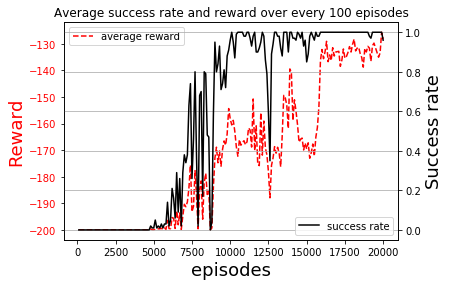

In [71]:
# Create a figure and the first axis
fig, ax1 = plt.subplots()
# Plot average rewards on the first y-axis
ax1.plot(aggr_ep_rewards['ep'], aggr_ep_rewards['avg'], label='average reward', color='red', linestyle='--')
ax1.set_xlabel('episodes', fontsize='18')  # Common x-axis label
ax1.set_ylabel('Reward', color='red', fontsize='18')
ax1.tick_params(axis='y', labelcolor='red')

# Create a second y-axis for success rate
ax2 = ax1.twinx()
ax2.plot(aggr_ep_rewards['ep'], aggr_ep_rewards['success'], label='success rate', color='black', linestyle='-')
ax2.set_ylabel('Success rate', color='black', fontsize='18')
ax2.tick_params(axis='y', labelcolor='black')
# Add a title
plt.title('Average success rate and reward over every 100 episodes')

# Optional: Add a legend
ax1.legend(loc=2)
ax2.legend(loc='lower right')

# Show the plot
plt.grid(True)
plt.show()